# Feature Engineering: Scaling, Normalization, and Standardization

![Machine Learning Lifecycle](machine_learning_lifecycle.webp)

Feature engineering is the process of creating, transforming, or selecting the most relevant variables 
(**features**) from raw data to improve model performance. 

Effective features help the model capture important patterns and relationships in the data.

Feature engineering directly contributes to model building in the following ways:

- Well-designed features allow models to learn complex patterns more effectively.
- Reduces noise and irrelevant information, improving prediction accuracy.
- Helps prevent overfitting by emphasizing meaningful data signals.
- Simplifies model interpretation by creating more informative and understandable inputs.

There are various techniques used in feature engineering, such as **scaling**, **normalization**, and **standardization**.  
Let's explore some of them.

## <br>1. Absolute Maximum Scaling

**Absolute Maximum Scaling** rescales each feature by dividing all values
by the maximum absolute value of that feature.<br>
This ensures that the feature values fall within the range **-1 to 1**.

While this method is simple and useful in some contexts, it is **highly sensitive to outliers**.<br>
Outliers can skew the maximum absolute value and negatively impact scaling quality.

### Formula

$$
X_{\text{scaled}} =
\frac{X_i}{\max(|X|)}
$$

### Key Characteristics

- Scales values between **-1 and 1**
- Preserves the sign of the original data
- Sensitive to outliers,
  making it less suitable for noisy datasets



#### <br>Example

Suppose we have the following feature values:

$$
X = [-50, -25, 0, 25, 50]
$$


#### Step 1: Find the Maximum Absolute Value

$$
\max(|X|) = 50
$$


#### Step 2: Apply Absolute Maximum Scaling

$$
X_{\text{scaled}} = \frac{X}{\max(|X|)} = \frac{X}{50}
$$


#### Step 3: Scaled Values

- $-50 \rightarrow -1.0$
- $-25 \rightarrow -0.5$
- $0 \rightarrow 0.0$
- $25 \rightarrow 0.5$
- $50 \rightarrow 1.0$


#### Final Scaled Feature

$$
X_{\text{scaled}} = [-1.0, -0.5, 0.0, 0.5, 1.0]
$$




### Code Example

We will first **load the dataset**.


In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('SampleFile.csv')

print(df)
# The select_dtypes method is used to select columns in a DataFrame based on their data types.
# By using include=[np.number], we are selecting only the columns that contain numeric data types
df = df.select_dtypes(include=[np.number])
df.head()

      LotArea  MSSubClass
0        8450          60
1        9600          20
2       11250          60
3        9550          70
4       14260          60
...       ...         ...
1455     7917          60
1456    13175          20
1457     9042          70
1458     9717          20
1459     9937          20

[1460 rows x 2 columns]


,LotArea,MSSubClass
0,8450,60
1,9600,20
2,11250,60
3,9550,70
4,14260,60


### Performing Absolute Maximum Scaling

- Computes the maximum absolute value **per column** using  
  $$max(|X|) = \text{np.max}(\text{np.abs}(X), \text{axis}=0)$$

- Scales each feature by dividing every value by its column’s maximum absolute value:

$$
X_{\text{scaled}} = \frac{X}{\max(|X|)}
$$

- This transformation scales all feature values to the range **$[-1, 1]$**.

- Displays the first few rows of the scaled dataset using:

```python
scaled_df.head()


    LotArea  MSSubClass
0  0.039258    0.315789
1  0.044600    0.105263
2  0.052266    0.315789
3  0.044368    0.368421
4  0.066250    0.315789


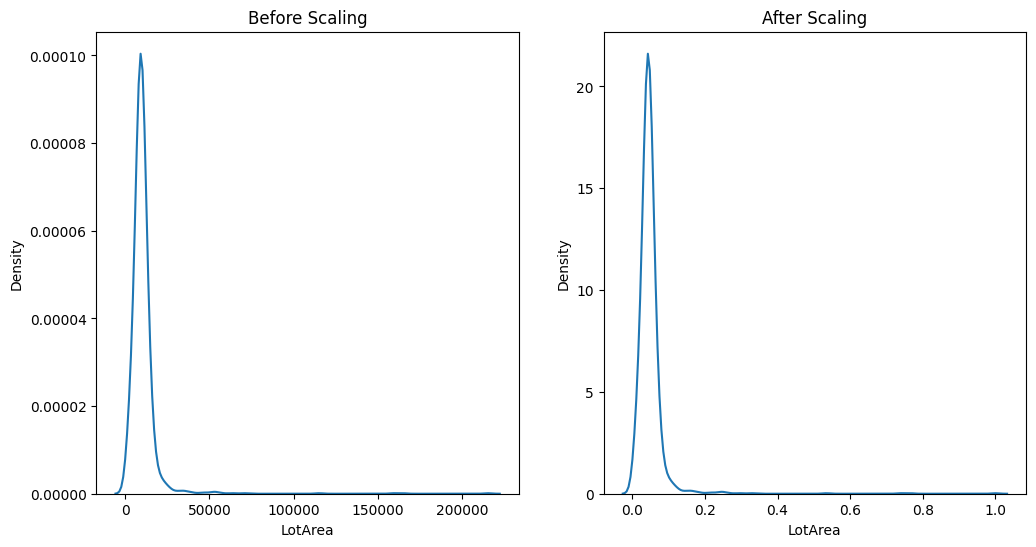

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

max_abs = np.max(np.abs(df), axis=0)    # axis=0 means column-wise i.e., for each feature
scaled_df = df / max_abs
print(scaled_df.head())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Before Scaling
# ax=ax1 means: Draw this plot INSIDE the left subplot
ax1.set_title('Before Scaling')
sns.kdeplot(df['LotArea'], ax=ax1)  # kernel density estimate plot

# After Scaling
# ax=ax2 means: Draw this plot INSIDE the right subplot
ax2.set_title('After Scaling')
sns.kdeplot(scaled_df['LotArea'], ax=ax2)   # kernel density estimate plot
plt.show()

## <br>2. Min-Max Scaling

**Min-Max Scaling** transforms features by subtracting the minimum value and dividing by the difference 
between the maximum and minimum values.<br>
This method maps feature values to a specified range, commonly **0 to 1**, preserving the original distribution shape.

However, it is **sensitive to outliers** because the min and max values can be skewed by extreme data points.

### Formula

$$
X_{\text{scaled}} = \frac{X_i - X_{\min}}{X_{\max} - X_{\min}}
$$

### Key Characteristics

- Scales features to a fixed range (typically **0 to 1**)
- Preserves the shape of the original distribution
- Sensitive to outliers, as extreme values affect both $X_{\min}$ and $X_{\max}$



#### <br>Example

Suppose we have the following feature values:

$$
X = [10, 20, 30, 40, 50]
$$


#### Step 1: Find the Minimum and Maximum Values

$$
X_{\min} = 10, \quad X_{\max} = 50
$$


#### Step 2: Apply Min-Max Scaling

$$
X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}} = \frac{X - 10}{50 - 10} = \frac{X - 10}{40}
$$


#### Step 3: Scaled Values

- $10 \rightarrow 0.00$
- $20 \rightarrow 0.25$
- $30 \rightarrow 0.50$
- $40 \rightarrow 0.75$
- $50 \rightarrow 1.00$


#### Final Scaled Feature

$$
X_{\text{scaled}} = [0.00, 0.25, 0.50, 0.75, 1.00]
$$

Scaled DataFrame:
    LotArea  MSSubClass
0  0.033420    0.235294
1  0.038795    0.000000
2  0.046507    0.235294
3  0.038561    0.294118
4  0.060576    0.235294


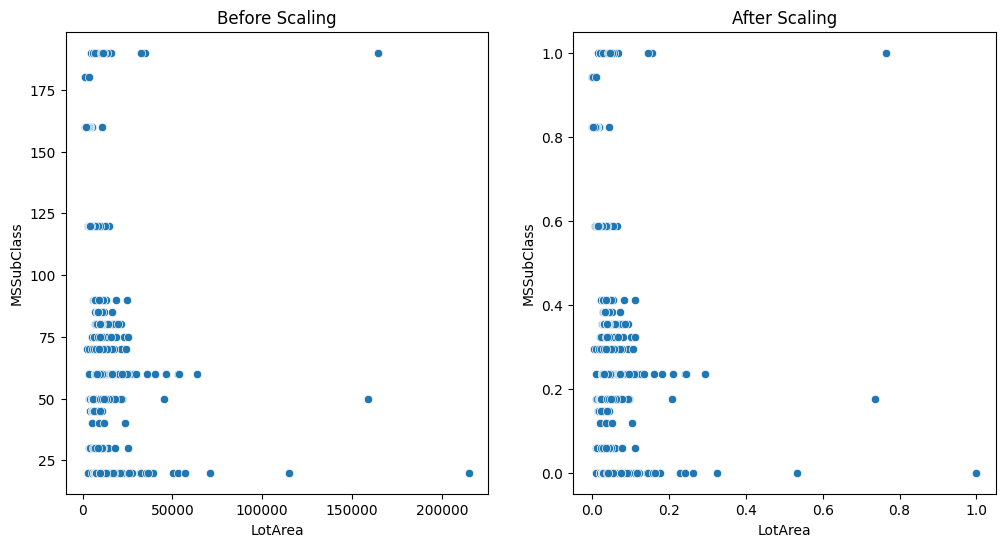

In [3]:
from sklearn.preprocessing import MinMaxScaler

# Keep a copy of the original data for comparison
df_original = df.copy()

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Converting the scaled_data (which is a NumPy array) back to a DataFrame for better visualization
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)  # it keeps the original column names
print("Scaled DataFrame:")
print(scaled_df.head())

# Visualization to compare original and scaled data with scatter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Before Scaling
# A scatter plot is a type of data visualization that displays values for two variables for a set of data points.
ax1.set_title('Before Scaling')
sns.scatterplot(x=df_original['LotArea'], y=df_original['MSSubClass'], ax=ax1)

# After Scaling
ax2.set_title('After Scaling')
sns.scatterplot(x=scaled_df['LotArea'], y=scaled_df['MSSubClass'], ax=ax2)
plt.show()

## <br>3. Vector Normalization (L2)

<img src="text-similarity.png" width="800">
 
### Formula

$$
X_{\text{normalized}} = \frac{X}{\|X\|} = \frac{X}{\sqrt{\sum_{i=1}^{n} X_i^2}}
$$

| Aspect | Vector Normalization (L2) | Min-Max Scaling |
|--------|---------------------------|-----------------|
| **Operates on** | Rows (samples) | Columns (features) |
| **Output** | Vector length = 1 | Values in $[0, 1]$ |
| **Preserves** | Direction | Relative distances |
| **Use case** | Cosine similarity, text/embeddings | Neural networks, KNN |

---

### Why Use Vector Normalization?

When you care about the **direction** of data, not its **magnitude**:

- **Text similarity:** Two documents with the same word ratios but different lengths should be considered similar
- **Embeddings:** Compare semantic meaning regardless of vector scale
- **Cosine similarity:** Requires unit vectors to work properly

---

### Quick Example

**Vector Normalization** on row $[2, 3, 6]$:
$$\|X\| = \sqrt{4 + 9 + 36} = 7 \quad \Rightarrow \quad X_{\text{norm}} = [0.29, 0.43, 0.86]$$

**Min-Max Scaling** on column $[2, 5, 6]$:
$$X_{\text{scaled}} = [0, 0.75, 1]$$

---

### One-Line Takeaway

> **Min-Max** → fix feature ranges (columns)  
> **Vector Norm** → fix sample lengths (rows)

Original DataFrame (first 5 rows):
   LotArea  MSSubClass
0     8450          60
1     9600          20
2    11250          60
3     9550          70
4    14260          60 

Normalized DataFrame (first 5 rows):
    LotArea  MSSubClass
0  0.999975    0.007100
1  0.999998    0.002083
2  0.999986    0.005333
3  0.999973    0.007330
4  0.999991    0.004208

Vector lengths after normalization (should be ~1.0):
0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64


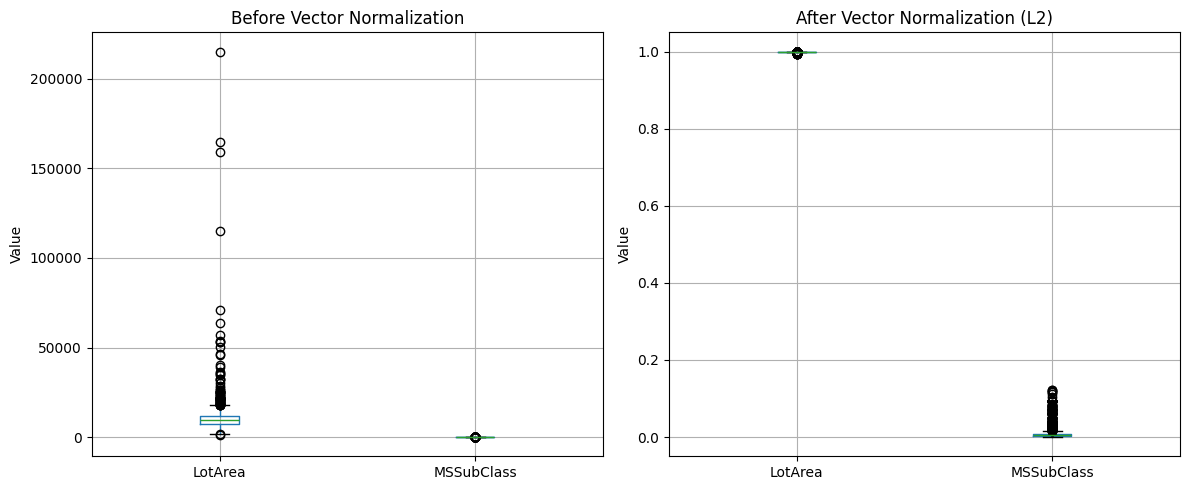

In [4]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')  # L2 norm (Euclidean)
normalized_data = normalizer.fit_transform(df)

print("Original DataFrame (first 5 rows):")
print(df.head(), "\n")

# Convert to DataFrame for better visualization
normalized_df = pd.DataFrame(normalized_data, columns=df.columns)
print("Normalized DataFrame (first 5 rows):")
print(normalized_df.head())

# Verify: each row should have length = 1
# Remind: axis=1 means row-wise operation, axis=0 means column-wise operation
row_lengths = np.sqrt((normalized_df ** 2).sum(axis=1))
print(f"\nVector lengths after normalization (should be ~1.0):")
print(row_lengths.head())

# Visualization: Compare original vs normalized using box plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before Normalization
axes[0].set_title('Before Vector Normalization')
df[['LotArea', 'MSSubClass']].boxplot(ax=axes[0])
axes[0].set_ylabel('Value')

# After Normalization
axes[1].set_title('After Vector Normalization (L2)')
normalized_df[['LotArea', 'MSSubClass']].boxplot(ax=axes[1])
axes[1].set_ylabel('Value')

# Vector Normalization fitted plots
plt.tight_layout()
plt.show()

## <br>4. Standardization (Z-Score)

**Standardization** centers features by subtracting the mean and scales them by dividing by the standard deviation.<br>
This transforms features to have **zero mean** and **unit variance** (why unit variance not unit standart deviation?).

This assumption of normal distribution often benefits models like **linear regression**, **logistic regression**, 
and **neural networks** by improving convergence speed and stability.

### Formula

$$
X_{\text{scaled}} = \frac{X_i - \mu}{\sigma}
$$

where $\mu$ = mean, $\sigma$ = standard deviation.

### Key Characteristics

- Produces features with **mean = 0** and **variance = 1**
- Effective for data approximately **normally distributed**
- Less sensitive to outliers than Min-Max scaling
- Preserves the shape of the original distribution



#### <br>Example

Suppose we have the following feature values:

$$
X = [10, 20, 30, 40, 50]
$$


#### Step 1: Calculate Mean and Standard Deviation

$$
\mu = \frac{10 + 20 + 30 + 40 + 50}{5} = 30
$$

$$
\sigma = \sqrt{\frac{(10-30)^2 + (20-30)^2 + (30-30)^2 + (40-30)^2 + (50-30)^2}{5}} = \sqrt{200} \approx 14.14
$$


#### Step 2: Apply Standardization

$$
X_{\text{scaled}} = \frac{X - 30}{14.14}
$$


#### Step 3: Scaled Values

- $10 \rightarrow -1.41$
- $20 \rightarrow -0.71$
- $30 \rightarrow 0.00$
- $40 \rightarrow 0.71$
- $50 \rightarrow 1.41$


#### Final Standardized Feature

$$
X_{\text{scaled}} = [-1.41, -0.71, 0.00, 0.71, 1.41]
$$

Standardized DataFrame:
    LotArea  MSSubClass
0 -0.207142    0.073375
1 -0.091886   -0.872563
2  0.073480    0.073375
3 -0.096897    0.309859
4  0.375148    0.073375


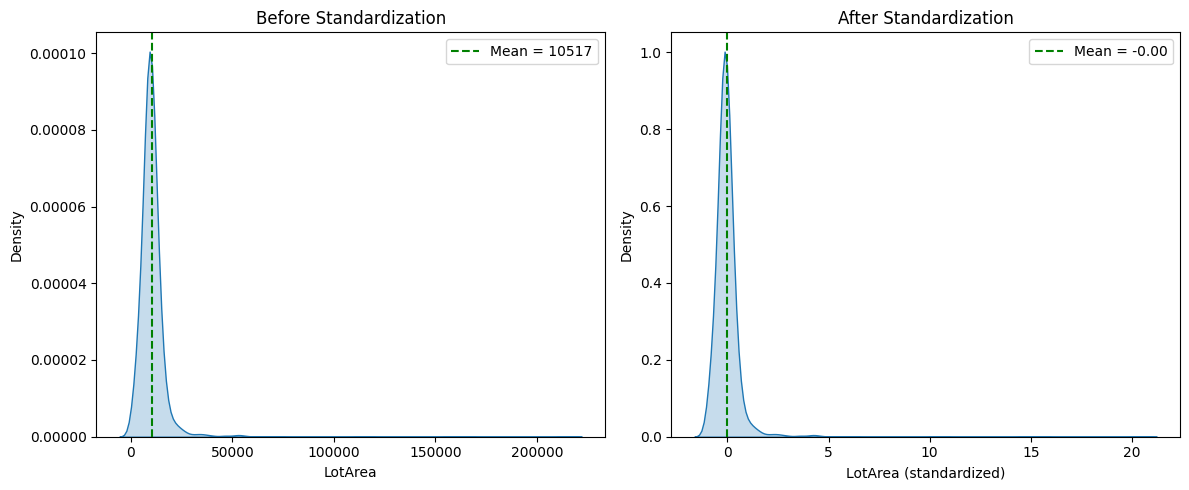

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print("Standardized DataFrame:")
print(scaled_df.head())

# Visualization: Normal distribution with means
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before Standardization
axes[0].set_title('Before Standardization')
sns.kdeplot(df['LotArea'], ax=axes[0], fill=True)
axes[0].axvline(x=df['LotArea'].mean(), color='green', linestyle='--', label=f'Mean = {df["LotArea"].mean():.0f}')
axes[0].set_xlabel('LotArea')
axes[0].legend()

# After Standardization
axes[1].set_title('After Standardization')
sns.kdeplot(scaled_df['LotArea'], ax=axes[1], fill=True)
axes[1].axvline(x=scaled_df['LotArea'].mean(), color='green', linestyle='--', label=f'Mean = {scaled_df["LotArea"].mean():.2f}')
axes[1].set_xlabel('LotArea (standardized)')
axes[1].legend()

plt.tight_layout()
plt.show()

## <br>5. Robust Scaling

**Robust Scaling** uses the **median** and **interquartile range (IQR)** instead of the mean and standard deviation.<br>
This makes the transformation **robust to outliers** and skewed distributions.

It is highly suitable when the dataset contains **extreme values** or **noise**.

### Formula

$$
X_{\text{scaled}} = \frac{X_i - X_{\text{median}}}{\text{IQR}}
$$

where $\text{IQR} = Q_3 - Q_1$ (interquartile range).

### Key Characteristics

- Reduces influence of outliers by centering on **median**
- Scales based on **IQR**, which captures the middle 50% spread
- Does not bound values to a specific range
- Best choice for **skewed data** with outliers



#### <br>Example with Outlier

Suppose we have the following feature values (notice the outlier **150**):

$$
X = [12, 13, 15, 16, 17, 18, 19, 22, 29, 150]
$$


#### Step 1: Find Q1, Median (Q2), and Q3

- **Q1** (25th percentile): median of lower half $[12, 13, 15, 16, 17]$ = **15**
- **Median (Q2)**: average of 5th and 6th values = $\frac{17 + 18}{2}$ = **17.5**
- **Q3** (75th percentile): median of upper half $[18, 19, 22, 29, 150]$ = **22**


#### Step 2: Calculate IQR

$$
\text{IQR} = Q_3 - Q_1 = 22 - 15 = 7
$$


#### Step 3: Apply Robust Scaling

$$
X_{\text{scaled}} = \frac{X - 17.5}{7}
$$


#### Step 4: Scaled Values

| Original | Calculation | Scaled |
|----------|-------------|--------|
| 12 | $(12 - 17.5) / 7$ | -0.79 |
| 13 | $(13 - 17.5) / 7$ | -0.64 |
| 15 | $(15 - 17.5) / 7$ | -0.36 |
| 16 | $(16 - 17.5) / 7$ | -0.21 |
| 17 | $(17 - 17.5) / 7$ | -0.07 |
| 18 | $(18 - 17.5) / 7$ | 0.07 |
| 19 | $(19 - 17.5) / 7$ | 0.21 |
| 22 | $(22 - 17.5) / 7$ | 0.64 |
| 29 | $(29 - 17.5) / 7$ | 1.64 |
| **150** | $(150 - 17.5) / 7$ | **18.93** |

---

### Why Robust Scaling?

The outlier (150) becomes 18.93 — it's still large, but **it doesn't distort the scaling of other values**.

With StandardScaler, the outlier would shift the mean and inflate the std, affecting ALL values.

Robust Scaled DataFrame:
    LotArea  MSSubClass
0 -0.254076         0.2
1  0.030015        -0.6
2  0.437624         0.2
3  0.017663         0.4
4  1.181201         0.2


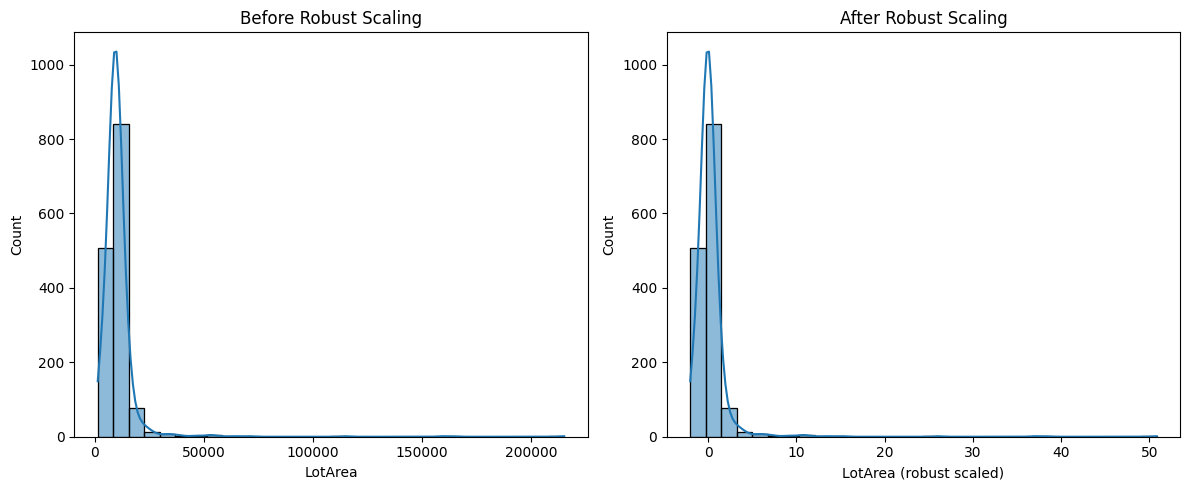

In [6]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_data = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
print("Robust Scaled DataFrame:")
print(scaled_df.head())

# Visualization: Compare original vs robust scaled using histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before Robust Scaling
axes[0].set_title('Before Robust Scaling')
sns.histplot(df['LotArea'], bins=30, kde=True, ax=axes[0])
axes[0].set_xlabel('LotArea')

# After Robust Scaling
axes[1].set_title('After Robust Scaling')
sns.histplot(scaled_df['LotArea'], bins=30, kde=True, ax=axes[1])
axes[1].set_xlabel('LotArea (robust scaled)')
plt.tight_layout()
plt.show()

## <br>Comparison of Various Feature Scaling Techniques

Let's see the key differences across the five main feature scaling techniques commonly used in machine learning preprocessing.

| Type | Method Description | Sensitivity to Outliers | Typical Use Cases |
|------|-------------------|------------------------|-------------------|
| **Absolute Maximum Scaling** | Divides values by max absolute value in each feature | High | Sparse data, simple scaling |
| **Min-Max Scaling (Normalization)** | Scales features to $[0, 1]$ by min-max normalization | High | Neural networks, bounded input features |
| **Normalization (Vector Norm)** | Scales each sample vector to unit length (norm = 1) | Not applicable (per row) | Direction-based similarity, text classification |
| **Standardization (Z-Score)** | Centers features to mean 0 and scales to unit variance | Moderate | Most ML algorithms, assumes approx. normal data |
| **Robust Scaling** | Centers on median and scales using IQR | Low | Data with outliers, skewed distributions |

---

### Advantages of Feature Scaling

- **Improves Model Performance:** Enhances accuracy and predictive power by presenting features in comparable scales.

- **Speeds Up Convergence:** Helps gradient-based algorithms train faster and more reliably.

- **Prevents Feature Bias:** Avoids dominance of large-scale features, ensuring fair contribution from all features.

- **Increases Numerical Stability:** Reduces risks of overflow/underflow in computations.

- **Facilitates Algorithm Compatibility:** Makes data suitable for distance- and gradient-based models like SVM, KNN, and neural networks.